## Oscillateur harmonique

On cherche à réaliser l'étude d'un oscillateur harmonique à 1 dimension, modèle omniprésent en physique. On ajoutera à ce modèle une analyse du bruit. On réalise toute la partie calcul numérique sur fortran. Les données seront alors répertoriés dans un fichier nommé "OH.dat".

Le fichier fortran est directement sur mon Github, on s'intéresse ici à la récupération des données et à leur exoloitation sous Python.

---

# 1: Analyse des données sous Python.

On importe les modules nécessaires.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

On représente la position de l'oscillateur harmonique en fonction du temps. On prend soin de faire apparaitre les valeurs de xthéorique,ximplicite et xexplicite.

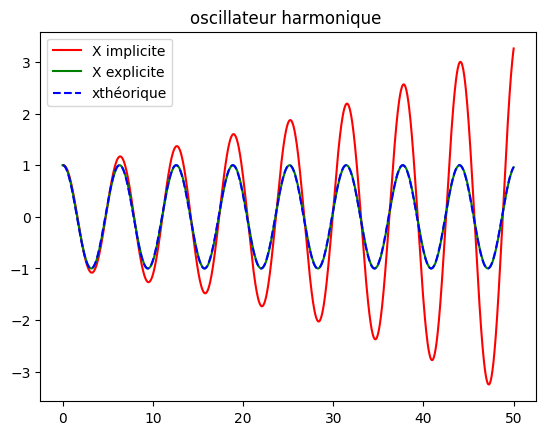

In [5]:
nomFichier = 'OH.dat'

data=np.genfromtxt(nomFichier)

data = np.genfromtxt(nomFichier)


t = data[:,0]
XEI = data[:,1]
XEE = data[:,2]
Xtheo = data[:,3]

plt.figure()
plt.plot(t,XEI,'r',label='X implicite')
plt.plot(t,XEE,'g',label='X explicite')
plt.plot(t,Xtheo,'--b',label="xthéorique")
plt.legend()
plt.title('oscillateur harmonique ')
plt.show()

Pour cette première partie, on observe que les résultats obtenus avec la méthode 'x explicite' sont les plus proches du modèle théorique de l'étude. dans le cas présent, on déduit que la meilleure méthode d'itération dans l'algorithme d'Euler est la méthode explicite dans ce cas précis. 

---

# 2/ Ajout de bruit et analyse fréquentielle.

Dans cette seconde partie, on ajoute la partie bruit sur nos valeurs de xthéorique avant de réaliser une analyse fréquentielle.

a. Ajout du bruit 

In [7]:
noise = np.random.normal(0, 0.1, len(Xtheo))
X_noisy = Xtheo + noise

b. visualisation du bruit 

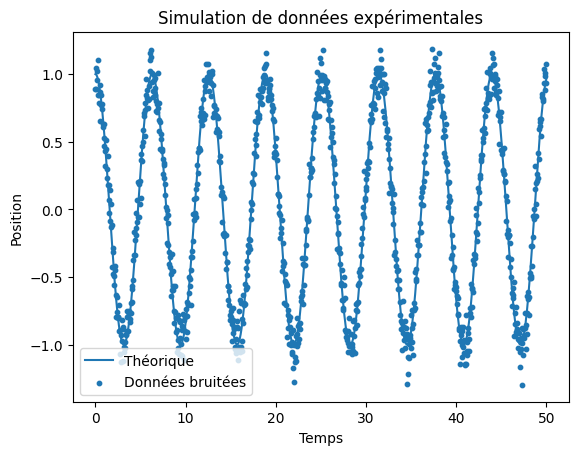

In [8]:
plt.figure()

plt.plot(t, Xtheo, label="Théorique")
plt.scatter(t, X_noisy, s=10, label="Données bruitées")

plt.xlabel("Temps")
plt.ylabel("Position")
plt.title("Simulation de données expérimentales")
plt.legend()
plt.show()

Ici, on voit que les données bruités oscillent autour de la courbe, on déduit que cela est du à des imprécisions lors des mesures expérimentales. Dans le cas actuel, plus le bruit est loin de la courbe théorique et plus l'erreur de manipulation est grande tandis que plus le bruit est proche de la courbe et plus la donnée théorique est précise.

Pour conclure, on voit clairement que le bruit reste proche de la courbe théorique montrant alors la fiabilité du modèle théorique.

C. Analyse fréquentielle 

Importation des modules nécesssaires (fft = fast Fourier transform)

In [10]:
from scipy.fft import fft, fftfreq

On introduit les paramètres d'échantillonages 

In [11]:
N = len(t) #nombre total de point de mesure 
dt = t[1] - t[0] #pas de temps 

Calcul de la transformée de Fourier

In [14]:
yf = fft(X_noisy)
xf = fftfreq(N, dt)

Visualisation du spectre 

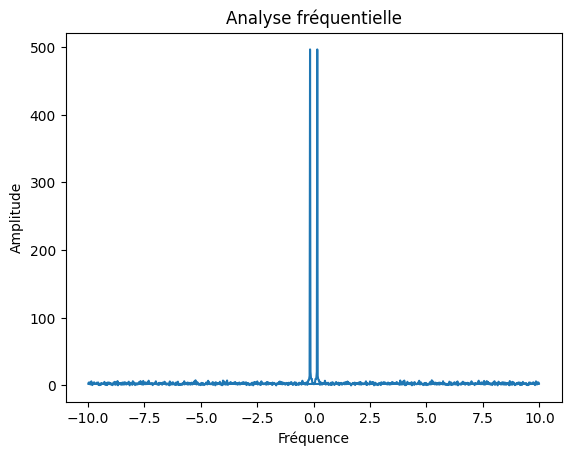

In [15]:
plt.figure()
plt.plot(xf, np.abs(yf))

plt.title("Analyse fréquentielle")
plt.xlabel("Fréquence")
plt.ylabel("Amplitude")
plt.show()

On obtient cette analyse fréquentielle grace à une rapide transformée de fourrier, les deux pics centraux très proche du zéro sont synonymes de la fréquence propre de l'oscillateur. De plus, on observe un plateau de bruit très faible sur tout le spectre, ceci provient probablement de l'accumulation d'erreurs engendré par l'algorithme d'Euler.

---

## Conclusion 

L'objectif de cette étude était de simuler le comportement de l'oscillateur harmponique 1D et d'évaluer la robustesse de l'analyse fréquentielle face à des données expérimentales simulées. 
L'algorithme d'Euler a permis d'obtenir une trajectoire oscillatoire, bien que ce modèle présente une instabilité numérique, il reproduit bien la période d'oscillation sur court terme. 
L'ajout d'un bruit aléatoire sur la position simule les incertitudes de mesure d'une expérience réelle, visuellement le signal devient 'sale' mais on garde bien le caractère oscillatoire du sytème.
La transformée de Fourier nous a permis de réaliser l'analyse fréquentielle du système, affichant ainsi un pic d'amplitude correspindant à la fréquence propre de l'oscillateur harmonique, tout en gardant le 'bruit' étalé sur tout le spectre. 
En résumé, cette analyse fréquentielle permet de garder le caractère physique du système même lorsque le signal temporelle est degradé, on peut donc conclure que l'analyse fréquentielle est bien plus précis que le travail sur la courbe bruitée.